<a href="https://colab.research.google.com/github/dharshana2806/EV-fleet-Data/blob/main/EV_Car_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()

Saving EV_Fleet_Synthetic_Dataset_10000_50Columns.csv to EV_Fleet_Synthetic_Dataset_10000_50Columns (1).csv


In [5]:
import pandas as pd
df = pd.read_csv(r"/content/EV_Fleet_Synthetic_Dataset_10000_50Columns.csv")

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

In [99]:
df.head(5)

,Record_ID,Vehicle_ID,Vehicle_Number,Manufacturer,Model,Vehicle_Type,Manufacture_Year,Purchase_Date,Garage_ID,Charging_Station_ID,...,Garage_Days,Service_Type,Next_Service_Date,Driver_Rating,Vehicle_Health,Day,Month_Number,Weekday,Hour,Time_Period
0,1,EV0083,TN17AB9313,Volvo,Volvo X2,SUV,2024,23-05-2024,G03,CS003,...,1,Minor,17-06-2025,4.1,Good,19,3,Wednesday,13,Afternoon
1,2,EV0075,TN33AB2688,BYD,BYD X3,Hatchback,2026,07-10-2024,G15,CS035,...,2,Minor,01-11-2025,4.6,Good,3,8,Sunday,6,Morning
2,3,EV0021,TN87AB2199,Mercedes-Benz,Mercedes-Benz X3,SUV,2022,26-12-2024,G01,CS021,...,0,Minor,20-01-2026,4.9,Poor,22,10,Wednesday,5,Morning
3,4,EV0179,TN67AB5662,Volvo,Volvo X2,Hatchback,2025,10-02-2025,G19,CS019,...,3,Major,07-03-2026,4.1,Good,7,12,Sunday,11,Morning
4,5,EV0210,TN58AB4780,Hyundai,Hyundai X3,SUV,2026,13-10-2024,G10,CS010,...,5,Minor,07-11-2025,3.9,Poor,9,8,Saturday,4,Morning


In [100]:
df.tail(5)

,Record_ID,Vehicle_ID,Vehicle_Number,Manufacturer,Model,Vehicle_Type,Manufacture_Year,Purchase_Date,Garage_ID,Charging_Station_ID,...,Garage_Days,Service_Type,Next_Service_Date,Driver_Rating,Vehicle_Health,Day,Month_Number,Weekday,Hour,Time_Period
9995,9996,EV0062,TN43AB6935,Tata,Tata X2,SUV,2023,29-09-2024,G02,CS022,...,2,Major,24-10-2025,3.9,Excellent,26,7,Saturday,19,Evening
9996,9997,EV0013,TN97AB1186,Tesla,Tesla X1,Hatchback,2024,14-10-2024,G13,CS013,...,1,Minor,08-11-2025,4.6,Excellent,10,8,Sunday,17,Evening
9997,9998,EV0099,TN12AB2275,BYD,BYD X3,SUV,2025,30-03-2024,G19,CS019,...,0,Major,24-04-2025,3.6,Excellent,24,1,Friday,1,Morning
9998,9999,EV0138,TN47AB3282,Hyundai,Hyundai X3,Sedan,2024,23-07-2024,G18,CS018,...,0,Major,17-08-2025,3.2,Excellent,19,5,Monday,17,Evening
9999,10000,EV0027,TN53AB2480,BYD,BYD X3,Hatchback,2023,27-08-2024,G07,CS027,...,1,Major,21-09-2025,4.1,Excellent,23,6,Monday,10,Morning


In [9]:
print(df.shape)

(10000, 47)


In [10]:
df.columns

Index(['Record_ID', 'Vehicle_ID', 'Vehicle_Number', 'Manufacturer', 'Model',
       'Vehicle_Type', 'Manufacture_Year', 'Purchase_Date', 'Garage_ID',
       'Charging_Station_ID', 'Driver_ID', 'Driver_Name', 'Driver_Age',
       'Driver_Experience', 'Trip_ID', 'Trip_Date', 'Trip_Start_Time',
       'Trip_End_Time', 'Month', 'Year', 'Vehicle_Status', 'Current_Location',
       'Battery_Percentage', 'Expected_Travel_Distance_km',
       'Actual_Distance_Travelled_km', 'Energy_Consumed_kWh',
       'Charging_Time_hr', 'Charging_Cost', 'Revenue_Generated',
       'Maintenance_Cost', 'Repair_Cost', 'Insurance_Cost',
       'Trip_Duration_Minutes', 'Average_Speed', 'Maximum_Speed',
       'Overspeed_Violation', 'Violation_Count', 'Accident', 'CO2_Saved_kg',
       'Weather', 'Road_Type', 'Garage_Visit', 'Garage_Days', 'Service_Type',
       'Next_Service_Date', 'Driver_Rating', 'Vehicle_Health'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 47 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Record_ID                     10000 non-null  int64  
 1   Vehicle_ID                    10000 non-null  object 
 2   Vehicle_Number                10000 non-null  object 
 3   Manufacturer                  10000 non-null  object 
 4   Model                         10000 non-null  object 
 5   Vehicle_Type                  10000 non-null  object 
 6   Manufacture_Year              10000 non-null  int64  
 7   Purchase_Date                 10000 non-null  object 
 8   Garage_ID                     10000 non-null  object 
 9   Charging_Station_ID           10000 non-null  object 
 10  Driver_ID                     10000 non-null  object 
 11  Driver_Name                   10000 non-null  object 
 12  Driver_Age                    10000 non-null  int64  
 13  Dr

In [12]:
df.dtypes

,0
Record_ID,int64
Vehicle_ID,object
Vehicle_Number,object
Manufacturer,object
Model,object
Vehicle_Type,object
Manufacture_Year,int64
Purchase_Date,object
Garage_ID,object
Charging_Station_ID,object


In [13]:
df.isnull().sum()

,0
Record_ID,0
Vehicle_ID,0
Vehicle_Number,0
Manufacturer,0
Model,0
Vehicle_Type,0
Manufacture_Year,0
Purchase_Date,0
Garage_ID,0
Charging_Station_ID,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.describe()

,Record_ID,Manufacture_Year,Driver_Age,Driver_Experience,Year,Battery_Percentage,Expected_Travel_Distance_km,Actual_Distance_Travelled_km,Energy_Consumed_kWh,Charging_Time_hr,...,Maintenance_Cost,Repair_Cost,Insurance_Cost,Trip_Duration_Minutes,Average_Speed,Maximum_Speed,Violation_Count,CO2_Saved_kg,Garage_Days,Driver_Rating
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,2024.003900,40.005200,12.953900,2025.0,58.643500,175.930500,167.076300,26.732208,2.262923,...,150.463500,201.014697,70.372283,190.940800,75.074600,95.022800,1.305800,20.049156,2.499400,3.99852
std,2886.89568,1.406799,10.665972,7.216508,0.0,22.256337,66.769011,88.572084,14.171533,1.012783,...,87.075744,115.724703,28.735879,98.533991,27.611579,26.262183,1.747396,10.628650,1.709237,0.57968
min,1.00000,2022.000000,22.000000,1.000000,2025.0,16.000000,48.000000,15.000000,2.400000,0.500000,...,4.500000,0.000000,20.000000,20.000000,15.000000,50.000000,0.000000,1.800000,0.000000,3.00000
25%,2500.75000,2023.000000,31.000000,7.000000,2025.0,40.000000,120.000000,89.000000,14.240000,1.390000,...,82.765000,99.900000,45.547500,106.000000,53.000000,72.000000,0.000000,10.680000,1.000000,3.50000
50%,5000.50000,2024.000000,40.000000,13.000000,2025.0,59.000000,177.000000,167.000000,26.720000,2.260000,...,138.405000,201.335000,70.260000,191.000000,75.000000,95.000000,0.000000,20.040000,2.000000,4.00000
75%,7500.25000,2025.000000,49.000000,19.000000,2025.0,78.000000,234.000000,244.000000,39.040000,3.150000,...,206.817500,301.732500,95.362500,276.000000,97.000000,118.000000,3.000000,29.280000,4.000000,4.50000
max,10000.00000,2026.000000,58.000000,25.000000,2025.0,101.000000,303.000000,320.000000,51.200000,4.000000,...,410.640000,399.910000,119.990000,360.000000,135.000000,140.000000,5.000000,38.400000,5.000000,5.00000


In [16]:
df.describe(include='all')

,Record_ID,Vehicle_ID,Vehicle_Number,Manufacturer,Model,Vehicle_Type,Manufacture_Year,Purchase_Date,Garage_ID,Charging_Station_ID,...,Accident,CO2_Saved_kg,Weather,Road_Type,Garage_Visit,Garage_Days,Service_Type,Next_Service_Date,Driver_Rating,Vehicle_Health
count,10000.00000,10000,10000,10000,10000,10000,10000.000000,10000,10000,10000,...,10000,10000.000000,10000,10000,10000,10000.000000,10000,10000,10000.00000,10000
unique,NaN,250,9934,12,12,3,NaN,365,20,40,...,2,NaN,3,2,2,NaN,2,365,NaN,4
top,NaN,EV0214,TN53AB8648,Tesla,Tesla X1,SUV,NaN,08-01-2025,G07,CS007,...,No,NaN,Sunny,City,No,NaN,Minor,02-02-2026,NaN,Good
freq,NaN,58,2,871,871,3369,NaN,46,554,309,...,9477,NaN,3388,5015,5014,NaN,5017,46,NaN,2543
mean,5000.50000,NaN,NaN,NaN,NaN,NaN,2024.003900,NaN,NaN,NaN,...,NaN,20.049156,NaN,NaN,NaN,2.499400,NaN,NaN,3.99852,NaN
std,2886.89568,NaN,NaN,NaN,NaN,NaN,1.406799,NaN,NaN,NaN,...,NaN,10.628650,NaN,NaN,NaN,1.709237,NaN,NaN,0.57968,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,2022.000000,NaN,NaN,NaN,...,NaN,1.800000,NaN,NaN,NaN,0.000000,NaN,NaN,3.00000,NaN
25%,2500.75000,NaN,NaN,NaN,NaN,NaN,2023.000000,NaN,NaN,NaN,...,NaN,10.680000,NaN,NaN,NaN,1.000000,NaN,NaN,3.50000,NaN
50%,5000.50000,NaN,NaN,NaN,NaN,NaN,2024.000000,NaN,NaN,NaN,...,NaN,20.040000,NaN,NaN,NaN,2.000000,NaN,NaN,4.00000,NaN
75%,7500.25000,NaN,NaN,NaN,NaN,NaN,2025.000000,NaN,NaN,NaN,...,NaN,29.280000,NaN,NaN,NaN,4.000000,NaN,NaN,4.50000,NaN


In [17]:
df['Trip_Date'] = pd.to_datetime(df['Trip_Date'], format='%d-%m-%Y')

In [18]:
df['Day'] = df['Trip_Date'].dt.day
df['Month_Number'] = df['Trip_Date'].dt.month
df['Year'] = df['Trip_Date'].dt.year
df['Weekday'] = df['Trip_Date'].dt.day_name()

In [19]:
df['Trip_Start_Time'] = pd.to_datetime(df['Trip_Start_Time'])

In [20]:
df['Hour'] = df['Trip_Start_Time'].dt.hour

In [21]:
def period(x):
  if x < 12:
        return "Morning"
  elif x < 17:
        return "Afternoon"
  elif x < 21:
        return "Evening"
  else:
        return "Night"
df['Time_Period'] = df['Hour'].apply(period)

In [101]:
df.head(5)

,Record_ID,Vehicle_ID,Vehicle_Number,Manufacturer,Model,Vehicle_Type,Manufacture_Year,Purchase_Date,Garage_ID,Charging_Station_ID,...,Garage_Days,Service_Type,Next_Service_Date,Driver_Rating,Vehicle_Health,Day,Month_Number,Weekday,Hour,Time_Period
0,1,EV0083,TN17AB9313,Volvo,Volvo X2,SUV,2024,23-05-2024,G03,CS003,...,1,Minor,17-06-2025,4.1,Good,19,3,Wednesday,13,Afternoon
1,2,EV0075,TN33AB2688,BYD,BYD X3,Hatchback,2026,07-10-2024,G15,CS035,...,2,Minor,01-11-2025,4.6,Good,3,8,Sunday,6,Morning
2,3,EV0021,TN87AB2199,Mercedes-Benz,Mercedes-Benz X3,SUV,2022,26-12-2024,G01,CS021,...,0,Minor,20-01-2026,4.9,Poor,22,10,Wednesday,5,Morning
3,4,EV0179,TN67AB5662,Volvo,Volvo X2,Hatchback,2025,10-02-2025,G19,CS019,...,3,Major,07-03-2026,4.1,Good,7,12,Sunday,11,Morning
4,5,EV0210,TN58AB4780,Hyundai,Hyundai X3,SUV,2026,13-10-2024,G10,CS010,...,5,Minor,07-11-2025,3.9,Poor,9,8,Saturday,4,Morning


In [102]:
print(df.shape)

(10000, 52)


In [24]:
df.isnull().sum()

,0
Record_ID,0
Vehicle_ID,0
Vehicle_Number,0
Manufacturer,0
Model,0
Vehicle_Type,0
Manufacture_Year,0
Purchase_Date,0
Garage_ID,0
Charging_Station_ID,0


In [25]:
df.fillna(method='ffill', inplace=True)

In [26]:
# Remove unnecessary column

In [27]:
ml_df = df.copy()
columns_to_drop = [
    'Record_ID',
    'Vehicle_ID',
    'Vehicle_Number',
    'Trip_ID',
    'Driver_ID',
    'Driver_Name',
    'Purchase_Date',
    'Trip_Date',
    'Trip_Start_Time',
    'Trip_End_Time',
    'Next_Service_Date',
    'Current_Location',
    'Garage_ID',
    'Charging_Station_ID',
    'Day',
    'Month_Number',
    'Weekday',
    'Hour',
    'Time_Period',
    'Year',
    'CO2_Saved_kg',
    'Insurance_Cost',
    'Repair_Cost',
    'Garage_Days',
    'Service_Type',
    'Driver_Rating',
    'Vehicle_Health',
    'Driver_Age',
    'Accident',
    'Weather',
    'Road_Type',
    'Expected_Travel_Distance_km'
]

ml_df = ml_df.drop(columns=columns_to_drop)

print("Shape:", ml_df.shape)
print(ml_df.columns)

Shape: (10000, 20)
Index(['Manufacturer', 'Model', 'Vehicle_Type', 'Manufacture_Year',
       'Driver_Experience', 'Month', 'Vehicle_Status', 'Battery_Percentage',
       'Actual_Distance_Travelled_km', 'Energy_Consumed_kWh',
       'Charging_Time_hr', 'Charging_Cost', 'Revenue_Generated',
       'Maintenance_Cost', 'Trip_Duration_Minutes', 'Average_Speed',
       'Maximum_Speed', 'Overspeed_Violation', 'Violation_Count',
       'Garage_Visit'],
      dtype='object')


In [28]:
 # Check Unique Values:

In [29]:
df.nunique()

,0
Record_ID,10000
Vehicle_ID,250
Vehicle_Number,9934
Manufacturer,12
Model,12
Vehicle_Type,3
Manufacture_Year,5
Purchase_Date,365
Garage_ID,20
Charging_Station_ID,40


In [30]:
df.rename(columns={
    'Actual_Distance_Travelled_km': 'Kilometer'
}, inplace=True)

In [31]:
 # Vehicle Status Distribution

In [32]:
df['Vehicle_Status'].value_counts()

,count
Vehicle_Status,
Running,2506
Charging,2505
Idle,2503
Maintenance,2486


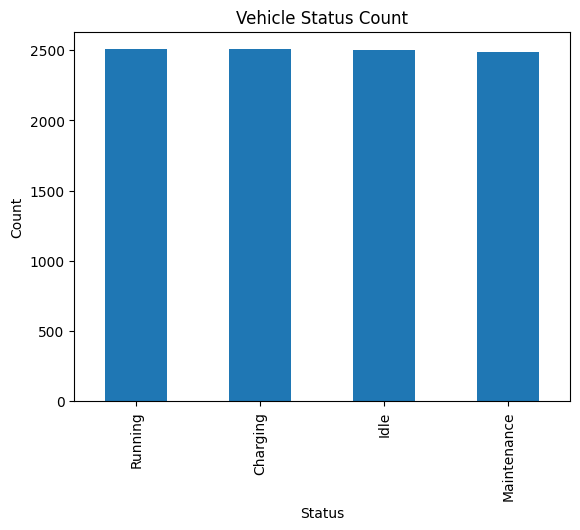

In [33]:
import matplotlib.pyplot as plt
df['Vehicle_Status'].value_counts().plot(kind='bar')
plt.title("Vehicle Status Count")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

In [34]:
 # Manufacturer Count

In [35]:
manufacturer_count = df.groupby('Manufacturer')['Vehicle_ID'].nunique()
print(manufacturer_count)

Manufacturer
Audi             21
BMW              21
BYD              21
Hyundai          21
Kia              21
MG               21
Mahindra         21
Mercedes-Benz    21
Nissan           20
Tata             21
Tesla            21
Volvo            20
Name: Vehicle_ID, dtype: int64


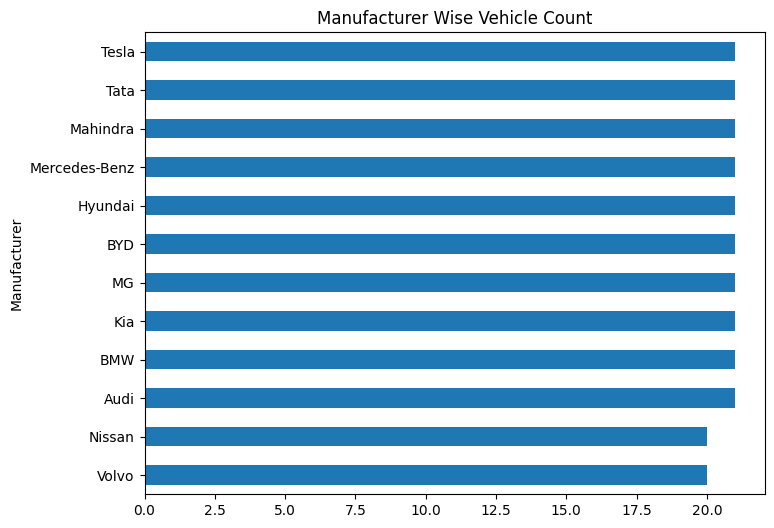

In [36]:
manufacturer_count.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Manufacturer Wise Vehicle Count")
plt.show()

In [37]:
# Running Vehicles Count

In [38]:
running = df[df['Vehicle_Status']=='Running']
print("Running Vehicles :", running['Vehicle_ID'].nunique())

Running Vehicles : 250


In [39]:
# Charging vehicle count

In [40]:
charging = df[df['Vehicle_Status']=='Charging']
print("Charging Vehicles :", charging['Vehicle_ID'].nunique())

Charging Vehicles : 250


In [41]:
 # Garage Count

In [42]:
print(df['Garage_ID'].nunique())

20


In [43]:
 # Garage Wise Vehicle Count

In [44]:
garage = df.groupby('Garage_ID')['Vehicle_ID'].nunique()
garage

,Vehicle_ID
Garage_ID,
G01,13
G02,13
G03,13
G04,13
G05,13
G06,13
G07,13
G08,13
G09,13


In [45]:
# Revenue Generated

In [46]:
manufacturer_revenue = df.groupby('Manufacturer')['Revenue_Generated'].sum()
manufacturer_revenue

,Revenue_Generated
Manufacturer,
Audi,2094710.29
BMW,2132662.94
BYD,2157726.73
Hyundai,2110465.95
Kia,2131940.43
MG,2035697.09
Mahindra,1973377.32
Mercedes-Benz,2149712.21
Nissan,1934736.08


In [47]:
 # Manufacturer Wise Revenue

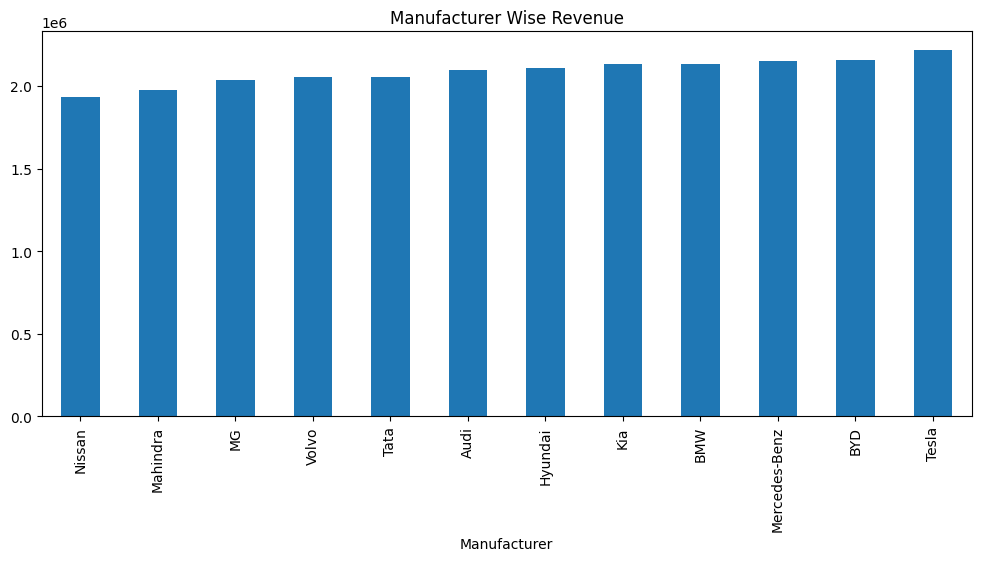

In [48]:
manufacturer_revenue.sort_values().plot(kind='bar', figsize=(12,5))
plt.title("Manufacturer Wise Revenue")
plt.show()

In [49]:
 # Monthly Revenue

In [50]:
monthly_revenue = df.groupby('Month')['Revenue_Generated'].sum()
monthly_revenue

,Revenue_Generated
Month,
April,2170001.88
August,2013325.75
December,2134276.11
February,1992713.74
January,2199647.51
July,2069271.17
June,2006060.39
March,2111209.10
May,2247054.64


In [51]:
 # Vehicle Wise Revenue

In [52]:
vehicle_revenue = df.groupby('Vehicle_ID')['Revenue_Generated'].sum()
vehicle_revenue

,Revenue_Generated
Vehicle_ID,
EV0001,72423.88
EV0002,88187.78
EV0003,70455.54
EV0004,95533.76
EV0005,102844.79
...,...
EV0246,110193.36
EV0247,103774.89
EV0248,106655.47


In [53]:
 # Driver Wise Revenue

In [54]:
driver_revenue = df.groupby('Driver_Name')['Revenue_Generated'].sum()
driver_revenue

,Revenue_Generated
Driver_Name,
Driver_1,72423.88
Driver_10,116796.93
Driver_100,93875.94
Driver_101,81610.20
Driver_102,113013.18
...,...
Driver_95,104378.46
Driver_96,91597.98
Driver_97,120480.83


In [55]:
 # Highest revenue driver

In [56]:
print(driver_revenue.idxmax())
print(driver_revenue.max())

Driver_127
144272.73


In [57]:
# Lowest revenue driver

In [58]:
print(driver_revenue.idxmin())
print(driver_revenue.min())

Driver_179
53521.57


In [59]:
 # Maintenance Cost Month Wise

In [60]:
maintenance = df.groupby('Month')['Maintenance_Cost'].sum()
maintenance

,Maintenance_Cost
Month,
April,126922.09
August,122611.43
December,127263.40
February,119327.08
January,134342.85
July,121614.67
June,123201.93
March,127727.08
May,136570.72


In [61]:
 # Battery Percentage Analysis

In [62]:
print("Average Battery :",df['Battery_Percentage'].mean())
print("Maximum Battery :",df['Battery_Percentage'].max())
print("Minimum Battery :",df['Battery_Percentage'].min())

Average Battery : 58.6435
Maximum Battery : 101
Minimum Battery : 16


In [63]:
#  Present Battery percentage

In [64]:
import pandas as pd
MAX_RANGE = 400
ml_df['Expected_Travel_Distance'] = (
    ml_df['Battery_Percentage'] / 100
) * MAX_RANGE
result = ml_df[['Battery_Percentage', 'Expected_Travel_Distance']]
print(result.head(20))

    Battery_Percentage  Expected_Travel_Distance
0                   42                     168.0
1                   82                     328.0
2                   62                     248.0
3                   84                     336.0
4                   26                     104.0
5                   43                     172.0
6                   40                     160.0
7                   44                     176.0
8                   83                     332.0
9                   40                     160.0
10                  33                     132.0
11                  68                     272.0
12                  66                     264.0
13                  43                     172.0
14                  95                     380.0
15                  29                     116.0
16                  51                     204.0
17                  27                     108.0
18                  52                     208.0
19                  

In [65]:
display_df = result.copy()
display_df['Battery_Percentage'] = display_df['Battery_Percentage'].round(1).astype(str) + " %"
display_df['Expected_Travel_Distance'] = display_df['Expected_Travel_Distance'].round(2).astype(str) + " km"
display(display_df.head(20))

,Battery_Percentage,Expected_Travel_Distance
0,42 %,168.0 km
1,82 %,328.0 km
2,62 %,248.0 km
3,84 %,336.0 km
4,26 %,104.0 km
5,43 %,172.0 km
6,40 %,160.0 km
7,44 %,176.0 km
8,83 %,332.0 km
9,40 %,160.0 km


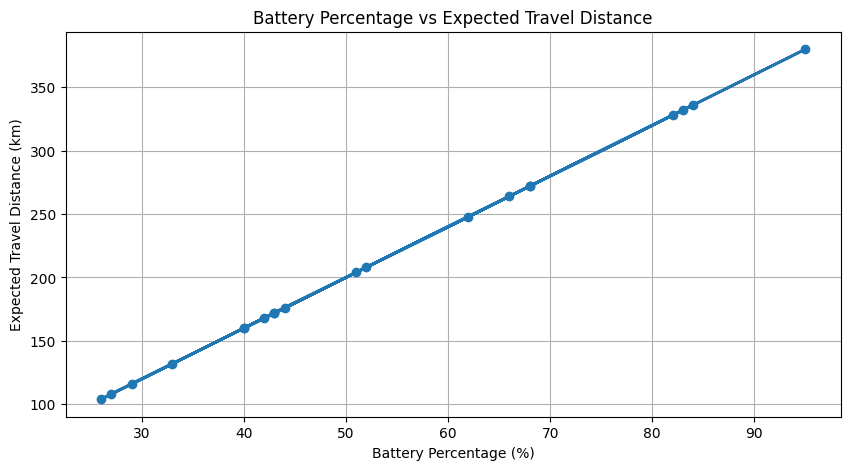

In [66]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(
    ml_df['Battery_Percentage'].head(20),
    ml_df['Expected_Travel_Distance'].head(20),
    marker='o',
    linewidth=2
)
plt.title("Battery Percentage vs Expected Travel Distance")
plt.xlabel("Battery Percentage (%)")
plt.ylabel("Expected Travel Distance (km)")
plt.grid(True)
plt.show()

In [67]:
 # Expected Distance Analysis

In [68]:
df['Expected_Travel_Distance_km'].describe()

,Expected_Travel_Distance_km
count,10000.000000
mean,175.930500
std,66.769011
min,48.000000
25%,120.000000
50%,177.000000
75%,234.000000
max,303.000000


In [69]:
 # Overspeed Analysis

In [70]:
overspeed = df[df['Overspeed_Violation']=='Yes']
overspeed.groupby('Driver_Name')['Violation_Count'].sum().sort_values(ascending=False)

,Violation_Count
Driver_Name,
Driver_197,81
Driver_81,81
Driver_183,80
Driver_193,79
Driver_69,79
...,...
Driver_225,27
Driver_19,26
Driver_26,25


In [71]:
# Top 10 drivers

In [72]:
overspeed.groupby('Driver_Name')['Violation_Count'].sum().sort_values(ascending=False).head(10)

,Violation_Count
Driver_Name,
Driver_197,81
Driver_81,81
Driver_183,80
Driver_193,79
Driver_69,79
Driver_169,78
Driver_130,77
Driver_63,77
Driver_112,76


In [73]:
# Overspeed by Time Period

In [74]:
df.groupby('Time_Period')['Violation_Count'].sum()

,Violation_Count
Time_Period,
Afternoon,2671
Evening,2137
Morning,6689
Night,1561


In [75]:
# Find the fastest vehicle based on Maximum Speed with all its details

In [76]:
fastest_vehicle = df.groupby('Model')[['Average_Speed','Maximum_Speed']].mean()
fastest_vehicle['Speed_Score'] = (
    fastest_vehicle['Average_Speed'] + fastest_vehicle['Maximum_Speed']
) / 2
fastest_vehicle.sort_values('Speed_Score', ascending=False).head(10)

,Average_Speed,Maximum_Speed,Speed_Score
Model,,,
BMW X2,76.438882,96.211874,86.325378
Mahindra X2,76.370603,96.066583,86.218593
Volvo X2,75.433661,95.875921,85.654791
BYD X3,75.447831,95.779601,85.613716
Audi X1,75.638526,95.116528,85.377527
Tesla X1,74.840413,95.113662,84.977038
Kia X1,74.982122,94.920143,84.951132
MG X1,75.159756,94.519512,84.839634
Mercedes-Benz X3,74.552204,94.481439,84.516821


In [77]:
 # Month - wise for fastest vehicle

In [78]:
monthly_fastest = df.groupby(['Month','Model'])['Maximum_Speed'].mean().reset_index()
monthly_fastest = monthly_fastest.sort_values(['Month','Maximum_Speed'], ascending=[True,False])
monthly_fastest

,Month,Model,Maximum_Speed
0,April,Audi X1,100.064516
8,April,Nissan X3,98.295775
9,April,Tata X2,97.029851
7,April,Mercedes-Benz X3,96.985714
2,April,BYD X3,96.649351
...,...,...,...
132,September,Audi X1,93.074627
134,September,BYD X3,92.676923
140,September,Nissan X3,91.230769
135,September,Hyundai X3,90.723077


In [79]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ml_df.select_dtypes(include='object').columns:
    ml_df[col] = le.fit_transform(ml_df[col])
ml_df.head()

,Manufacturer,Model,Vehicle_Type,Manufacture_Year,Driver_Experience,Month,Vehicle_Status,Battery_Percentage,Actual_Distance_Travelled_km,Energy_Consumed_kWh,...,Charging_Cost,Revenue_Generated,Maintenance_Cost,Trip_Duration_Minutes,Average_Speed,Maximum_Speed,Overspeed_Violation,Violation_Count,Garage_Visit,Expected_Travel_Distance
0,11,11,1,2024,3,7,3,42,217,34.72,...,758.02,3332.86,148.98,341,28,59,0,0,1,168.0
1,2,2,0,2026,21,1,3,82,88,14.08,...,248.89,1151.46,26.40,180,42,65,0,0,0,328.0
2,7,7,1,2022,14,10,2,62,168,26.88,...,627.94,2257.04,238.12,180,80,113,1,3,0,248.0
3,11,11,0,2025,22,2,0,84,48,7.68,...,128.34,790.62,93.99,146,125,139,1,4,1,336.0
4,3,3,1,2026,6,1,3,26,296,47.36,...,229.52,5879.94,88.80,293,122,140,1,3,1,104.0


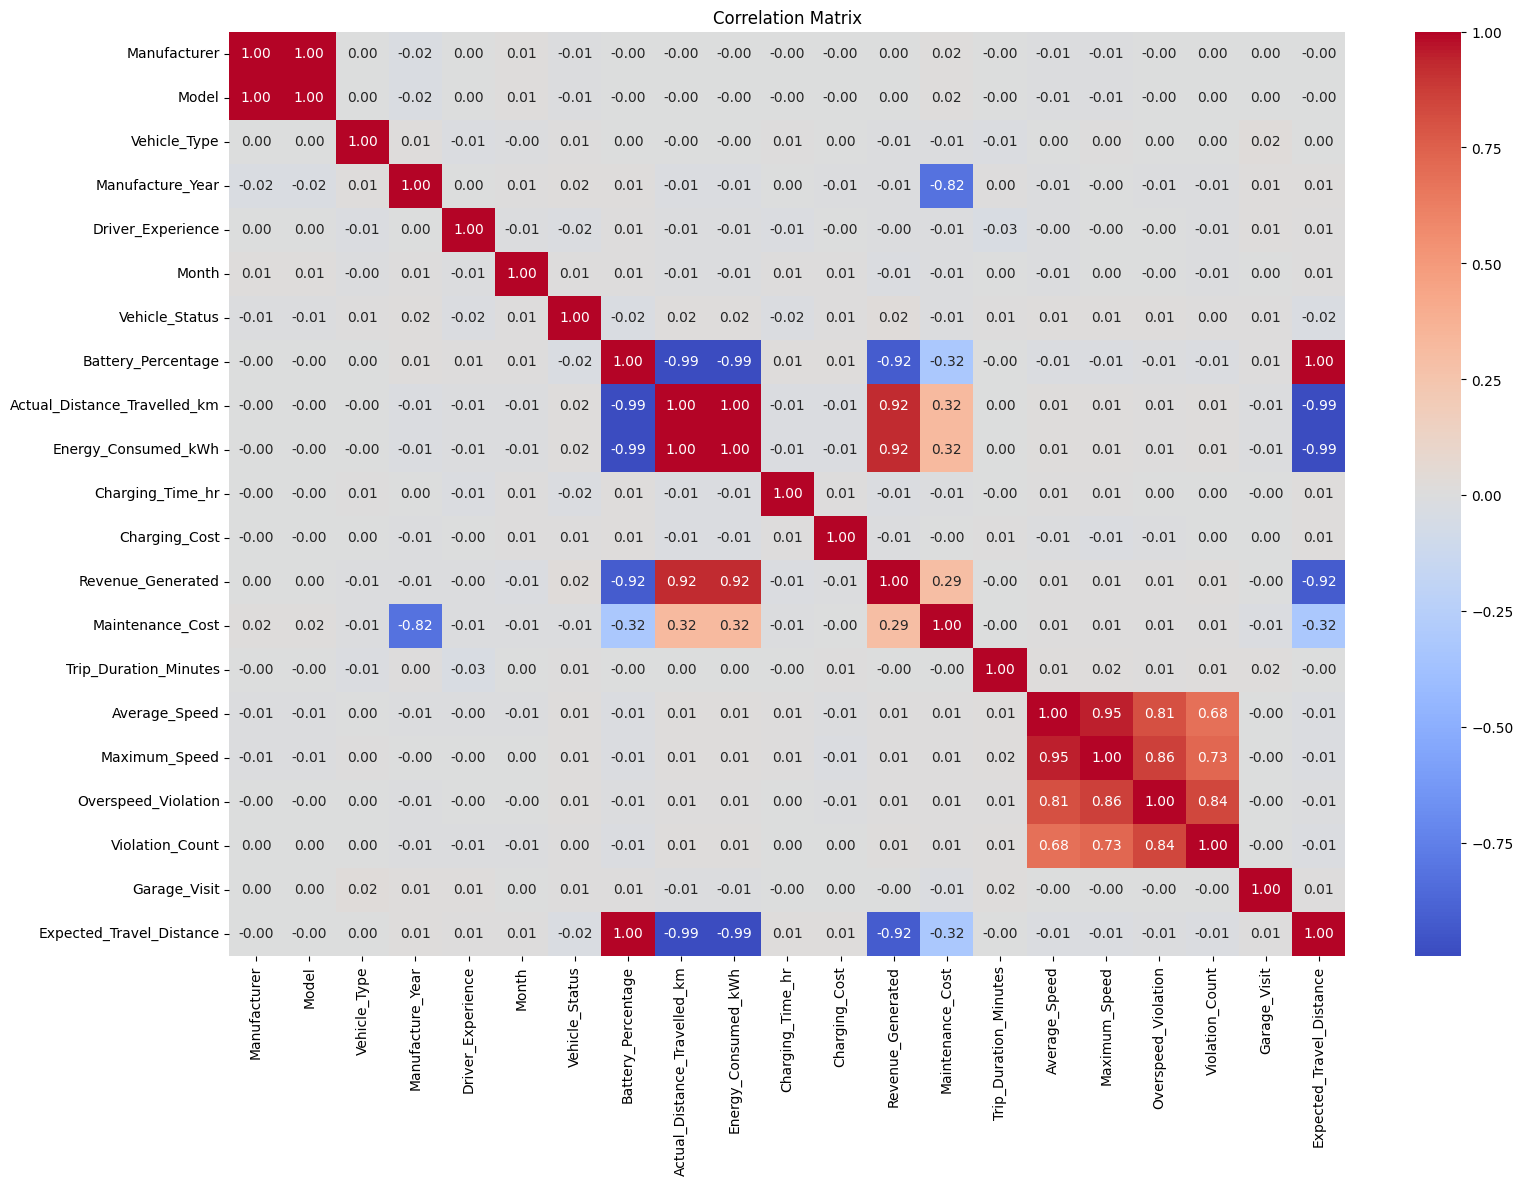

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(18,12))
corr = ml_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [81]:
corr_target = ml_df.corr()['Revenue_Generated'].sort_values(ascending=False)
print(corr_target)

Revenue_Generated               1.000000
Energy_Consumed_kWh             0.923974
Actual_Distance_Travelled_km    0.923974
Maintenance_Cost                0.292773
Vehicle_Status                  0.020823
Violation_Count                 0.012758
Average_Speed                   0.010207
Maximum_Speed                   0.009752
Overspeed_Violation             0.009534
Manufacturer                    0.002300
Model                           0.002300
Garage_Visit                   -0.000196
Trip_Duration_Minutes          -0.001362
Driver_Experience              -0.004747
Vehicle_Type                   -0.006329
Charging_Cost                  -0.007232
Manufacture_Year               -0.011188
Charging_Time_hr               -0.012805
Month                          -0.013631
Battery_Percentage             -0.918672
Expected_Travel_Distance       -0.918672
Name: Revenue_Generated, dtype: float64


In [82]:
y = ml_df['Revenue_Generated']

In [83]:
X = ml_df.drop('Revenue_Generated', axis=1)

In [87]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [88]:
print(X_train.shape)
print(X_test.shape)

(8000, 20)
(2000, 20)


In [90]:
# One hot encoding

In [89]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
numeric_features = X_train.select_dtypes(include=['int64','float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [91]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [92]:
y_pred = model.predict(X_test_scaled)

In [93]:
import sklearn
print(sklearn.__version__)

1.6.1


In [95]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 408.283421849286
MSE : 283183.6162537765
RMSE: 532.1499941311439
R2 Score: 0.8605971010673057


In [96]:
result = pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
result.head(20)

,Actual,Predicted
6252,3035.19,3343.119747
4684,619.77,626.500434
1731,2827.85,2335.306389
4742,1313.59,1729.655183
4521,886.74,943.859130
6340,3203.52,2759.392827
576,4607.73,4032.891651
5202,2495.26,2717.050927
6363,4044.67,4595.993428
439,2260.16,1927.086392


In [97]:
# Actual vs Predicted Graph

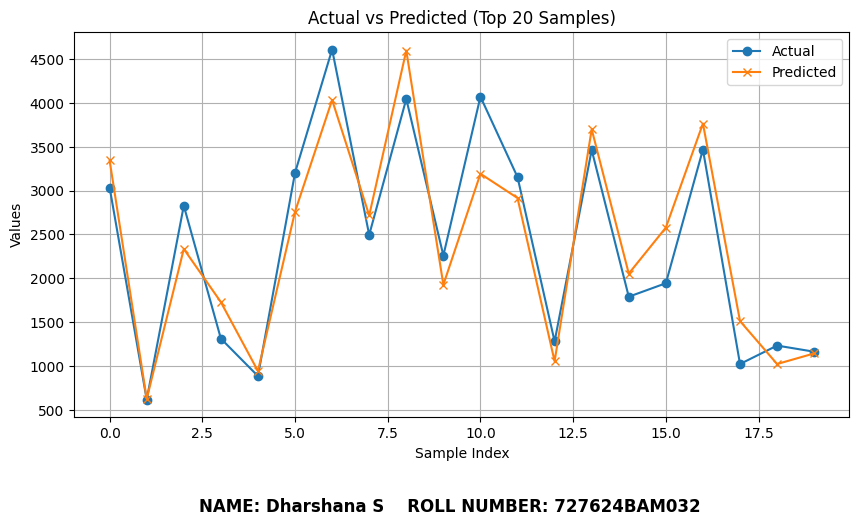

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
res20 = result.head(20).reset_index(drop=True)
plt.figure(figsize=(10,5))
plt.plot(res20.index, res20['Actual'], label='Actual', marker='o')
plt.plot(res20.index, res20['Predicted'], label='Predicted', marker='x')
plt.title("Actual vs Predicted (Top 20 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.figtext(
    0.5, -0.08,
    "NAME: Dharshana S    ROLL NUMBER: 727624BAM032",
    ha="center",
    fontsize=12,
    fontweight="bold"
)
plt.show()